In [183]:
#import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Customer Churn Risk & AI Retention Advisor

## Part 1: Business Framing & Exploratory Analysis

Task 1: Explore the Data as a KPI Story


### 1.1 Load the Data

In [184]:
dataset_url = 'https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv'

df = pd.read_csv(dataset_url)

In [185]:
df.shape

(7043, 21)

analysing the columns of the dataset

In [186]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [187]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### 1.2 KPI

Compute the overall churn rate as a KPI. Break it down by Contract type and by InternetService
type.

In [188]:
### checking the distribution of the churn rate(the target variable)
df.value_counts('Churn')

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [189]:
# percentage
df.value_counts('Churn', normalize=True) * 100


Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

let's plot it for a better understanding:

<Axes: xlabel='Churn'>

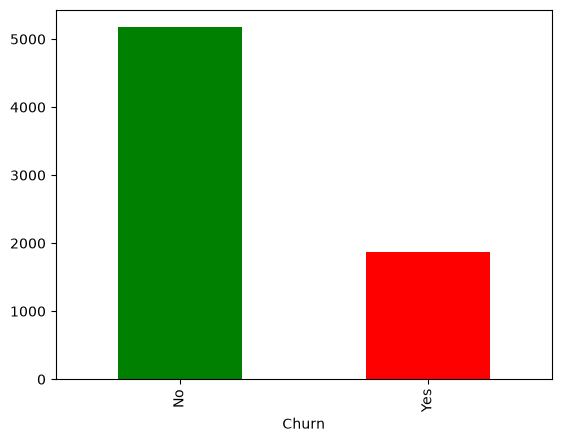

In [190]:
df['Churn'].value_counts().plot(kind='bar', color=['green', 'red'])

We can infer that the target variable shows a class imbalance: only 26.5% of customers in the dataset have churned, while the remaining 73.5% have not.

Now let's analyyze the churn rate relative to  Contract type and internet service

In [191]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [192]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


let's plot it:

<Axes: xlabel='Contract'>

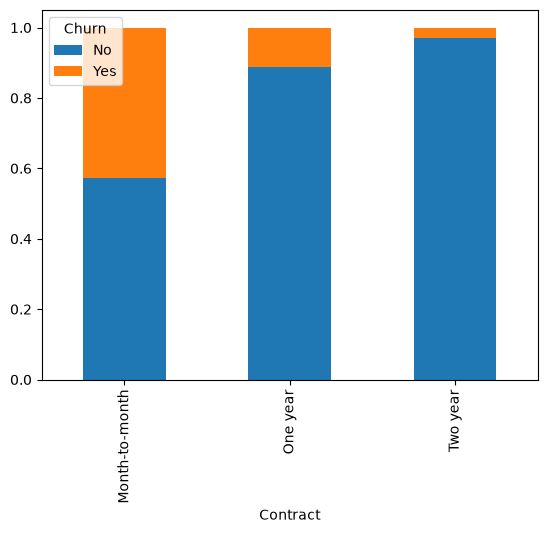

In [193]:
pd.crosstab(df['Contract'], df['Churn'], normalize='index').plot(kind='bar', stacked=True)

From the above plot, we can see that customers with month-to-month contracts have a higher churn rate than those with one-year or two-year contracts.

Customers with two-years contract has a very less churn rate.

from this we can infer that that customers who are on longer-term contracts are less likely to churn compared to those on shorter-term contracts.

Churn rate based on internet service

In [194]:
pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


<Axes: xlabel='InternetService'>

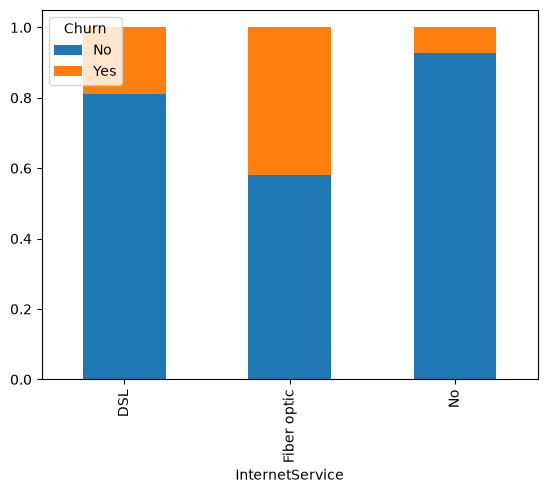

In [195]:
#let's visualize the churn rate based on the internet service type
pd.crosstab(df['InternetService'], df['Churn'], normalize='index').plot(kind='bar', stacked=True)

From the above plot, we can see that customers no internet service have less churn rate. And customer who have access to fiber optioc service is more likely to churn than the customer with the DSL internet service (which is relatively slower than the fiber optic).

In [196]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

### 1.3 Look at the correlation between tenure and Churn.

In [197]:
df['churn_binary'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

In [198]:
df['churn_binary'].corr(df['tenure'])

np.float64(-0.35222867011307807)

In [199]:
df[['churn_binary', 'tenure']].corr()

,churn_binary,tenure
churn_binary,1.000000,-0.352229
tenure,-0.352229,1.000000


The correlation value between churn and tenure is -0.35 which indicates a negative correlation.

### Analytical Question

Analytical Question: Report your overall churn rate and your churn rate by contract type, using your
own numbers. Month-to-month customers almost always churn more than annual-contract customers in
this data — explain in one paragraph why this is a correlation, not proof that switching everyone to
annual contracts would cause the same drop in churn (think about who self-selects into month-to-month
in the first place).

In [200]:
df.value_counts('Contract', normalize=True) * 100

Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64

I think month to month customers always churn more than annual-contract customers, maybe because in the above data set most 55% of the customers have chosen month-to-month contracts.

Most of these customers might have chosen month to month contract since they could stop their contract in any month and some people might have chosen it like a trial. So if the customer didn't like the service they can drop early if they're in a month to month contract. But for customers with yearly contract won't drop even if they're dissatisfied since they may lose the money.

## Part 2: Predictive Modelling & Business Segmentation

Task 2: Clean & Preprocess

### 2.1 Drop unnecessary columns and Fix inconsistent columns. Decide how to handle those rows and note why.

Let's look for columns with missing values:

In [201]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
churn_binary        0
dtype: int64

There're no missing values

In [202]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,churn_binary
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,0.265370
std,0.368612,24.559481,30.090047,0.441561
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,0.000000
50%,0.000000,29.000000,70.350000,0.000000
75%,0.000000,55.000000,89.850000,1.000000
max,1.000000,72.000000,118.750000,1.000000


In [203]:
df.duplicated().sum()

np.int64(0)

no duplicate records

Let's analyse each column values:

In [204]:
for col in df.columns:

    print(col)
    print(f'Unique value count = {df[col].nunique()}')
    print(f'Unique values = {np.sort(df[col].unique())}')
    print("-------------------")

customerID
Unique value count = 7043
Unique values = ['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']
-------------------
gender
Unique value count = 2
Unique values = ['Female' 'Male']
-------------------
SeniorCitizen
Unique value count = 2
Unique values = [0 1]
-------------------
Partner
Unique value count = 2
Unique values = ['No' 'Yes']
-------------------
Dependents
Unique value count = 2
Unique values = ['No' 'Yes']
-------------------
tenure
Unique value count = 73
Unique values = [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47
 48 49 50 51 52 53 54 55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71
 72]
-------------------
PhoneService
Unique value count = 2
Unique values = ['No' 'Yes']
-------------------
MultipleLines
Unique value count = 3
Unique values = ['No' 'No phone service' 'Yes']
-------------------
InternetService
Unique value count 

In [205]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
churn_binary          int64
dtype: object

CustomerID won't help in predication, so it can be dropped.

Also, the Total charges column dtype is str but it have continous numeric values:

In [206]:
df['TotalCharges'].unique()

<ArrowStringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 6531, dtype: str

Let's convert it to numeric:

In [207]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [208]:
df['TotalCharges'].dtype

dtype('float64')

In [209]:
df.isna().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
churn_binary         0
dtype: int64

There're 11 missing values in total charges

First let's check for any outliers in the Total Charges:


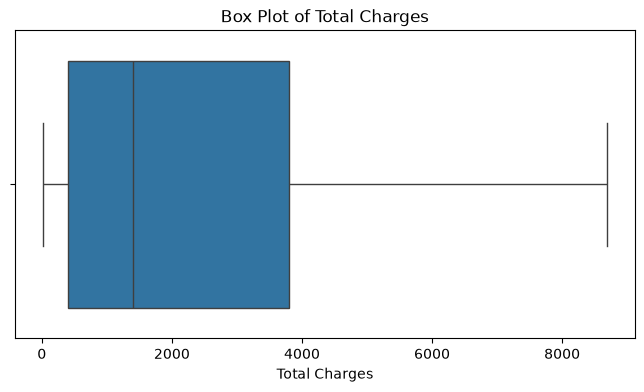

In [210]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df['TotalCharges'])

plt.title('Box Plot of Total Charges')
plt.xlabel('Total Charges')
plt.show()

There're no outliers it seems

In [211]:
df[df['TotalCharges'].isna()]['churn_binary'].value_counts()

churn_binary
0    11
Name: count, dtype: int64

Let's check the tenure of these records

In [212]:
df[df['TotalCharges'].isna()]['tenure']

488     0
753     0
936     0
1082    0
1340    0
3331    0
3826    0
4380    0
5218    0
6670    0
6754    0
Name: tenure, dtype: int64

The tenure of these customers are 0, so we can replace the missing TotalCharges with zero since their tenure is also zero.

In [213]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

We can see that all the records with missing value has churn as 0

In [214]:
# droppin customer id and dropping churn as well since we have created a binary column for churn
df = df.drop(['customerID', 'Churn'], axis=1)

In [215]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,churn_binary
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


### 2.3 Encode categoricals, scale numeric features.

In [216]:
cat_cols = df.select_dtypes(include='str').columns.tolist()

cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

##### Train Test Split

In [217]:
from sklearn.model_selection import train_test_split

X = df.drop('churn_binary', axis=1)
y = df['churn_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

##### Encoding

Let's perform one hot encoding on categorical columns:

In [218]:
cat_cols = X_train.select_dtypes(include='str').columns.tolist()
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [219]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

ohe = OneHotEncoder(
    drop='first',
    handle_unknown='ignore',
    sparse_output=False
)

X_train_encoded = ohe.fit_transform(X_train[cat_cols])
X_test_encoded = ohe.transform(X_test[cat_cols])

In [220]:
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_train.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=ohe.get_feature_names_out(cat_cols),
    index=X_test.index
)

In [221]:
X_train_encoded

,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
3738,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3151,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4860,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
3867,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
3810,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6303,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
6227,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4673,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
2710,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


##### Scaling

Selecting columns with continuous numeric values and applying standard scaling

In [222]:
from sklearn.preprocessing import StandardScaler

scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()


In [223]:
X_train_final = X_train_encoded.copy()
X_test_final = X_test_encoded.copy()

X_train_final[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_final[scale_cols] = scaler.transform(X_test[scale_cols])

In [224]:
X_train_final.head()

,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure,MonthlyCharges,TotalCharges
3738,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.102371,-0.521976,-0.262257
3151,1.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.711743,0.337478,-0.503635
4860,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,-0.793155,-0.809013,-0.749883
3867,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,1.0,1.0,1.0,0.0,0.0,-0.263980,0.284384,-0.172722
3810,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.281624,-0.676279,-0.989374


### Analytical Question A:
Your churn class is a minority class. Using your own numbers, explain why
accuracy alone would flatter this model, and what your recall figure tells the CFO about at-risk
customers your model would fail to flag.

### Analytical Question B:

Compare your training-set accuracy to your test-set accuracy for the complex
model. If there is a large gap, what does that tell you about trust — could you defend this model's
predictions to the board as-is, or would you simplify it first? If there is little gap, say so and explain why
that increases your confidence.

## Task 4: Feature Importance for Strategy

### 4.1 Extract and plot feature importance from your best model.

#### SelectKBest for feature selection


Let;s use select k best to identify our top 3 features:

In [226]:
from sklearn.feature_selection import SelectKBest, f_classif

k = 3

selector = SelectKBest(score_func=f_classif, k=k)
selector.fit(X_train_final, y_train)

kbest_scores = (
    pd.DataFrame({
        "Feature": X_train_final.columns,
        "F-Score": selector.scores_,
        "P-value": selector.pvalues_
    })
    .sort_values("F-Score", ascending=False)
    .head(k)
)

kbest_scores

,Feature,F-Score,P-value
26,tenure,763.890183,8.634920e-158
6,InternetService_Fiber optic,610.199922,5.320291e-128
24,PaymentMethod_Electronic check,595.424491,4.255626e-125


Hence these are the 3 best features after performing select k best

### Analytical Question:

Name your top 3 features. For each, write one sentence a retention manager could
act on directly (a specific contract change, billing method, or add-on service) — not a vague "improve
satisfaction" statement.

##### Top 3 Features

1. **Tenure** – Offer new customers discounts or incentives during their first few months to encourage them to stay longer.

2. **Internet Service – Fiber Optic** – Provide better pricing or special offers for fiber-optic customers to reduce the chance of them switching to another provider.

3. **Payment Method – Electronic Check** – Encourage electronic-check customers to switch to automatic bank transfer or credit card payments by offering small discounts or other incentives.


### 4.2 Model Building

In [227]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000, random_state=42)

logreg.fit(X_train_final, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

Evaluating the model:

In [233]:
from sklearn.metrics import accuracy_score, classification_report

# Predictions
y_pred = logreg.predict(X_test_final)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.801277501774308

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



## Task 5: Segment Customers for Targeting


### 5.1 Using tenure, MonthlyCharges and your model's predicted churn probability, cluster customers into 3–4 segments .

In [234]:
y_pred_proba = logreg.predict_proba(X_test_final)[:, 1]

In [235]:
cluster_data = pd.DataFrame({
    'tenure': X_test['tenure'],
    'MonthlyCharges': X_test['MonthlyCharges'],
    'churn_probability': y_pred_proba
})

Scaling the cluster data

In [236]:
from sklearn.preprocessing import StandardScaler

cluster_scaler = StandardScaler()

cluster_scaled = cluster_scaler.fit_transform(cluster_data)

In [237]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

cluster_data['Cluster'] = kmeans.fit_predict(cluster_scaled)

In [238]:
cluster_summary = (
    cluster_data
    .groupby('Cluster')
    [['tenure', 'MonthlyCharges', 'churn_probability']]
    .mean()
    .round(2)
)

cluster_summary

,tenure,MonthlyCharges,churn_probability
Cluster,,,
0,13.87,83.06,0.59
1,52.28,33.24,0.03
2,10.79,37.40,0.22
3,57.71,91.04,0.13


### 5.2 Give each segment a short business name based on its average tenure, spend, and churn risk (e.g."new, high-spend, high-risk")

Cluster 0 – New, High-Spend, High-Risk: Customers with relatively short tenure, high monthly charges, and a high probability of churning. They should be prioritized for retention efforts.

Cluster 1 – Loyal, Low-Spend, Low-Risk: Customers with long tenure, low monthly charges, and a very low probability of churning. They are stable customers who are likely to remain with the company.

Cluster 2 – New, Low-Spend, Moderate-Risk: Customers with relatively short tenure, low monthly charges, and a moderate probability of churning. They should be monitored and targeted with early retention offers.

Cluster 3 – Loyal, High-Spend, Low-Risk: Customers with long tenure, high monthly charges, and a low probability of churning. They are valuable and loyal customers who should be retained through loyalty benefits.


### Analytical Question:

Which single segment would you recommend the CFO fund a retention campaign
for first, and why — weigh both the churn risk and the revenue at stake, using your own segment
averages, not just "the riskiest one.

I would recommend **Cluster 0 – New, High-Spend, High-Risk** for the first retention campaign.

This segment has an average monthly charge of **$83.06** and the highest predicted churn probability of **59%**. Although Cluster 3 has a slightly higher average monthly charge of **$91.04**, its churn risk is only **13%**. Therefore, Cluster 0 has a much greater immediate revenue risk because customers are both paying relatively high amounts and are much more likely to leave. The company should prioritize this segment for retention offers such as introductory discounts, contract incentives, or service benefits.


## Part 3: GenAI Advisory Layer — Prompt Engineering & RAG

In this section, I build a simple advisory layer that combines the churn prediction model with a retention playbook. For a high-risk customer, I will identify the customer's churn probability, tenure, and top three features contributing to the prediction.

A simple retrieval step will then select the appropriate retention clause based on the customer's risk level and tenure. The retrieved clause and the selected customer features will be passed to an LLM to generate a short explanation for the retention agent.


Select a high-risk customer

In [241]:
# Predict churn probability for the test set
y_pred_proba = logreg.predict_proba(X_test_final)[:, 1]

# Create a DataFrame containing customer information
customer_predictions = pd.DataFrame({
    'tenure': X_test['tenure'].values,
    'churn_probability': y_pred_proba
}, index=X_test.index)

customer_predictions.head()

,tenure,churn_probability
437,72,0.046238
2280,8,0.657063
2235,41,0.060063
4460,18,0.409767
3761,72,0.022375


I first calculate the probability of churn for each customer using the Logistic Regression model. These probabilities are used to identify customers who meet the high-risk threshold defined in the retention playbook.


Find one high-risk customer

For this task, let's select a high-risk customer with probability ≥ 0.70.

In [242]:
high_risk_customers = customer_predictions[
    customer_predictions['churn_probability'] >= 0.70
]

high_risk_customers.head()

,tenure,churn_probability
6529,2,0.702190
6125,13,0.704432
5547,3,0.782725
346,2,0.785949
6633,1,0.767358


Now let's select one custome

In [243]:
customer_id = high_risk_customers.index[0]

customer = customer_predictions.loc[customer_id]

print("Customer index:", customer_id)
print("Tenure:", customer['tenure'])
print("Churn probability:", round(customer['churn_probability'], 3))

Customer index: 6529
Tenure: 2.0
Churn probability: 0.702


I select one customer whose predicted churn probability is at least 0.70. This customer will be used as the example for the GenAI advisory layer. The customer's tenure and predicted churn probability will be used when selecting the appropriate retention action.


Find the customer's top 3 contributing features

In [244]:
# Get the selected customer's feature values
customer_features = X_test_final.loc[customer_id]

# Get Logistic Regression coefficients
coefficients = pd.Series(
    logreg.coef_[0],
    index=X_train_final.columns
)

# Calculate contribution of each feature
contributions = customer_features * coefficients

# Get the 3 features with the largest absolute contributions
top_3_contributions = (
    contributions.abs()
    .sort_values(ascending=False)
    .head(3)
)

top_3_features = contributions.loc[top_3_contributions.index]

top_3_features

tenure                         1.541859
InternetService_Fiber optic    1.203319
PhoneService_Yes              -0.502487
dtype: float64

In [245]:
for feature, contribution in top_3_features.items():
    direction = "increases" if contribution > 0 else "decreases"
    print(f"{feature}: {direction} churn risk (contribution = {contribution:.3f})")

tenure: increases churn risk (contribution = 1.542)
InternetService_Fiber optic: increases churn risk (contribution = 1.203)
PhoneService_Yes: decreases churn risk (contribution = -0.502)


For the selected customer, I calculate the contribution of each feature using the Logistic Regression coefficients and the customer's feature values. I then rank the features by the absolute size of their contribution and select the top three. This gives a customer-specific explanation rather than using only the globally important features from the feature-selection step.


In [246]:
print("Customer Index:", customer_id)
print("Tenure:", round(customer['tenure'], 2), "months")
print("Churn Probability:", round(customer['churn_probability'], 3))

print("\nTop 3 Contributing Features:")
for feature, contribution in top_3_features.items():
    direction = "increases" if contribution > 0 else "decreases"
    print(f"- {feature}: {direction} churn risk")

Customer Index: 6529
Tenure: 2.0 months
Churn Probability: 0.702

Top 3 Contributing Features:
- tenure: increases churn risk
- InternetService_Fiber optic: increases churn risk
- PhoneService_Yes: decreases churn risk


In [247]:
retention_playbook = {
    "Clause 1": """Clause 1 — High Risk (probability ≥ 0.70): Offer a loyalty discount and a callback from a
retention specialist within 48 hours.""",

    "Clause 2": """Clause 2 — Moderate Risk (0.40–0.70): Send a targeted email highlighting an underused
service or a contract upgrade offer.""",

    "Clause 3": """Clause 3 — New Customer, Any Risk, Tenure < 3 months: Route to the onboarding team
instead of the standard retention flow.""",

    "Clause 4": """Clause 4 — Non-Discrimination Rule: Retention explanations must never state or imply

that gender, senior-citizen status, or family/partner status contributed to a customer's risk

score, even where a statistical correlation exists in the data."""
}

retention_playbook

{'Clause 1': 'Clause 1 — High Risk (probability ≥ 0.70): Offer a loyalty discount and a callback from a\nretention specialist within 48 hours.',
 'Clause 2': 'Clause 2 — Moderate Risk (0.40–0.70): Send a targeted email highlighting an underused\nservice or a contract upgrade offer.',
 'Clause 3': 'Clause 3 — New Customer, Any Risk, Tenure < 3 months: Route to the onboarding team\ninstead of the standard retention flow.',
 'Clause 4': "Clause 4 — Non-Discrimination Rule: Retention explanations must never state or imply\n\nthat gender, senior-citizen status, or family/partner status contributed to a customer's risk\n\nscore, even where a statistical correlation exists in the data."}

The retention playbook acts as the retrieval corpus for the advisory layer. It contains predefined actions for different risk levels and customer situations. I keep the clauses unchanged so that the LLM receives the original business rules as its source of guidance.


In [248]:
def retrieve_clause(churn_probability, tenure):
    
    # New customers are routed to onboarding regardless of risk
    if tenure < 3:
        return retention_playbook["Clause 3"]
    
    # High-risk customers
    elif churn_probability >= 0.70:
        return retention_playbook["Clause 1"]
    
    # Moderate-risk customers
    elif churn_probability >= 0.40:
        return retention_playbook["Clause 2"]
    
    # No retention clause specified for low-risk customers
    else:
        return None

In [249]:
retrieved_clause = retrieve_clause(
    customer['churn_probability'],
    customer['tenure']
)

print(retrieved_clause)

Clause 3 — New Customer, Any Risk, Tenure < 3 months: Route to the onboarding team
instead of the standard retention flow.


I use a simple rule-based retrieval method instead of a vector database. The customer's tenure and predicted churn probability are checked against the conditions in the playbook, and the matching clause is retrieved before the LLM is called. New customers with less than three months of tenure are given priority because the playbook states that this rule applies to customers with any risk level.


In [250]:
feature_information = []

for feature, contribution in top_3_features.items():
    direction = "increases" if contribution > 0 else "decreases"
    
    feature_information.append(
        f"{feature} ({direction} churn risk)"
    )

feature_information

['tenure (increases churn risk)',
 'InternetService_Fiber optic (increases churn risk)',
 'PhoneService_Yes (decreases churn risk)']

In [251]:
feature_text = ", ".join(feature_information)

print(feature_text)

tenure (increases churn risk), InternetService_Fiber optic (increases churn risk), PhoneService_Yes (decreases churn risk)


In [252]:
system_prompt = """
You are a customer retention advisory assistant.

Your task is to write a 3–4 sentence explanation for a retention agent.

Use ONLY:
1. The retrieved retention playbook clause.
2. The customer's tenure.
3. The customer's churn probability.
4. The three feature names and their supplied contribution directions.

Do not introduce any information that is not provided.

You MUST NOT mention, discuss, or imply that gender, SeniorCitizen,
Partner, or Dependents contributed to the customer's churn risk.

Do not make claims about causation. Treat the supplied features as
model-based indicators rather than proof that a feature caused churn.

Explain the customer's risk and recommend the action specified in the
retrieved clause.

Retrieved playbook clause:
{clause}

Customer tenure:
{tenure} months

Customer churn probability:
{probability}

Top contributing features:
{features}
"""

system_prompt = system_prompt.format(
    clause=retrieved_clause,
    tenure=round(customer['tenure'], 2),
    probability=round(customer['churn_probability'], 3),
    features=feature_text
)

print(system_prompt)


You are a customer retention advisory assistant.

Your task is to write a 3–4 sentence explanation for a retention agent.

Use ONLY:
1. The retrieved retention playbook clause.
2. The customer's tenure.
3. The customer's churn probability.
4. The three feature names and their supplied contribution directions.

Do not introduce any information that is not provided.

You MUST NOT mention, discuss, or imply that gender, SeniorCitizen,
Partner, or Dependents contributed to the customer's churn risk.

Do not make claims about causation. Treat the supplied features as
model-based indicators rather than proof that a feature caused churn.

Explain the customer's risk and recommend the action specified in the
retrieved clause.

Retrieved playbook clause:
Clause 3 — New Customer, Any Risk, Tenure < 3 months: Route to the onboarding team
instead of the standard retention flow.

Customer tenure:
2.0 months

Customer churn probability:
0.702

Top contributing features:
tenure (increases churn risk

The system prompt instructs the LLM to produce a short explanation based only on the retrieved business rule and the supplied model information. It also includes a clear non-discrimination instruction so that sensitive customer attributes are not used or implied in the explanation. The prompt also prevents the LLM from treating the model features as proof of causation.


In [254]:
!pip install google-genai

  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached pyasn1_modules-0.4.2-py3-none-any.whl.metadata (3.5 kB)
  Using cached pyasn1-0.6.4-py3-none-any.whl.metadata (8.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 8.5 MB/s  0:00:00
Using cached distro-1.9.0-py3-none-any.whl (20 kB)
Using cached tenacity-9.1.4-py3-none-any.whl (28 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 5.9 MB/s  0:00:00m eta 0:00:01
Using cached pyasn1_modules-0.4.2-py3-none-any.whl (181 kB)
Using cached pyasn1-0.6.4-py3-none-any.whl (84 kB)
Using cached sniffio-1.3.1-py3-none-any.whl (10 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [google-genai] [google-genai]


In [ ]:
from google import genai
import os

gemini_api_key = ""
client = genai.Client(api_key=gemini_api_key)

response = client.models.generate_content(
    model="gemini-2.5-flash-lite",
    contents=system_prompt
)

llm_output = response.text

print(llm_output)

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


This customer has a churn probability of 0.702, and a tenure of 2.0 months. The model indicates that shorter tenure and Fiber optic internet service increase churn risk, while Phone Service decreases it. As per Clause 3, since the customer's tenure is less than 3 months, they should be routed to the onboarding team instead of the standard retention flow.


In [258]:
exact_output = response.text

print("Exact LLM Output:")
print(exact_output)

Exact LLM Output:
This customer has a churn probability of 0.702, and a tenure of 2.0 months. The model indicates that shorter tenure and Fiber optic internet service increase churn risk, while Phone Service decreases it. As per Clause 3, since the customer's tenure is less than 3 months, they should be routed to the onboarding team instead of the standard retention flow.


In [259]:
advisory_record = {
    "Customer Index": customer_id,
    "Tenure": round(customer['tenure'], 2),
    "Churn Probability": round(customer['churn_probability'], 3),
    "Top 3 Features": list(top_3_features.index),
    "Retrieved Clause": retrieved_clause,
    "LLM Output": exact_output
}

advisory_record

{'Customer Index': np.int64(6529),
 'Tenure': np.float64(2.0),
 'Churn Probability': np.float64(0.702),
 'Top 3 Features': ['tenure',
  'InternetService_Fiber optic',
  'PhoneService_Yes'],
 'Retrieved Clause': 'Clause 3 — New Customer, Any Risk, Tenure < 3 months: Route to the onboarding team\ninstead of the standard retention flow.',
 'LLM Output': "This customer has a churn probability of 0.702, and a tenure of 2.0 months. The model indicates that shorter tenure and Fiber optic internet service increase churn risk, while Phone Service decreases it. As per Clause 3, since the customer's tenure is less than 3 months, they should be routed to the onboarding team instead of the standard retention flow."}

Finally, I record the exact response generated by the LLM along with the customer's risk probability, tenure, top three contributing features, and the retrieved retention clause. This makes the advisory process traceable from the original model prediction through retrieval to the final LLM explanation.


# Executive Memo

**To:** Chief Financial Officer
**Subject:** Customer Churn Retention Strategy

### Executive Summary

Our analysis identifies a high-risk customer group with a predicted churn probability of **59%**, making these customers the most important group to address because they combine a high likelihood of leaving with relatively high monthly spending.

### Recommended Target

I recommend targeting **Cluster 0 – New, High-Spend, High-Risk** first. These customers have an average tenure of **13.87 months**, average monthly charges of **$83.06**, and a predicted churn probability of **59%**. The main trade-off considered was revenue versus churn risk: Cluster 3 customers spend slightly more on average at **$91.04 per month**, but their churn probability is only **13%**. Therefore, Cluster 0 represents a greater immediate retention opportunity because the company is more likely to lose these relatively high-value customers.

### Monitoring

After launching the retention campaign, I would track the **actual churn rate of month-to-month customers after major competitor pricing changes or new offers**. If actual churn in this group starts increasing significantly while the model continues to predict lower risk, this would indicate that customer behavior has changed and the model should be retrained using more recent data.

### Governance

To prove that the non-discrimination rule was enforced, every generated explanation should be logged with the **exact retrieved playbook clause, prompt/policy version, customer features supplied to the LLM, and final explanation**, allowing an auditor to verify from the logs that Clause 4 was applied to every response.

### Cost Control

If explanations are required for every at-risk customer every week, I would **cache previously generated explanations and only call the LLM when a customer's risk tier, tenure, or top contributing features change**. Each cached explanation would remain linked to the exact playbook clause and version used to generate it, so reducing API calls would not break the citation and traceability requirement.

### Conclusion

The analysis suggests that retention resources should first focus on customers who combine **high churn risk with meaningful revenue at stake**. A targeted campaign for Cluster 0, combined with continuous monitoring, strong governance logs, and controlled LLM usage, would provide a practical approach to improving retention while managing operational and AI-related risks.
